# SPIDER v2 EDA

> Chinnappa, Praveen; Arokiya Dass, Rose Mary; mathur, yash (2025). SPIDER (v2): Synthetic Person Information Dataset for Entity Resolution. figshare. Dataset. https://doi.org/10.6084/m9.figshare.30472712.v2

*From source:*

### Dataset Schema

| Field | Description |
|--------|--------------|
| `record_id` | Unique identifier for each record |
| `cluster_id` | Identifier grouping a base record and its generated duplicates |
| `first_name` | First name of the person |
| `last_name` | Last name of the person |
| `email` | Email address (synthetically aligned to names) |
| `phone` | Phone number (generated using state-based area codes) |
| `dob` | Date of birth (ISO format) |
| `address` | Full address including street, city, state, and ZIP |
| `is_duplicate_of` | ID of the base record (null if original) |
| `duplication_rule` | Description of the duplication rule applied |
| `rule_category` | Short code representing the rule type |
| `is_duplicate` | Boolean flag (True/False) indicating whether the record is a duplicate |

### Duplicate Generation Rules

10,000 duplicates were generated from base records using **seven real-world transformation rules**.

This is just for reference. For the purpose of the EDA and project we are going to asume we don't know the reasoning for duplication

| Rule | Description | Real-world Use Case |
|------|--------------|---------------------|
| 1 | Duplicate record with a variation in email address | Same person using multiple emails |
| 2 | Duplicate record with a variation in phone numbers | Same person using multiple phone numbers |
| 3 | Duplicate record with last-name variation | Name changes or data entry errors |
| 4 | Duplicate record with address variation | Same person maintaining multiple addresses or moving residences |
| 5 | Duplicate record with a nickname | Same person using formal and informal names (Robert → Bob, Elizabeth → Liz) |
| 6 | Duplicate record with minor spelling variations in first name | Legitimate entry or migration errors (Sara → Sarah) |
| 7 | Duplicate record with multiple individuals sharing the same email and last name but different DOBs | Shared household or family account (e.g., benefits, tax, insurance systems) |

Each duplicate record includes a `duplication_rule` tag and links back to its source via `is_duplicate_of`.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from random import seed

seed(5338)

In [2]:
path = r"C:\Users\Eduardo\Documents\MIACD\git\MIACD\DeepLearning\Deep_Entity_Resolution\data\raw\spider_dataset_v2_6_20251027_022215.csv"
df = pd.read_csv(path, dtype={'postal_code': str})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   record_id        50000 non-null  str  
 1   is_duplicate     50000 non-null  int64
 2   is_duplicate_of  10000 non-null  str  
 3   rule_id          50000 non-null  int64
 4   rule_category    50000 non-null  str  
 5   first_name       50000 non-null  str  
 6   last_name        50000 non-null  str  
 7   email            50000 non-null  str  
 8   phone            50000 non-null  str  
 9   dob              50000 non-null  str  
 10  street           50000 non-null  str  
 11  city             50000 non-null  str  
 12  state            50000 non-null  str  
 13  postal_code      50000 non-null  str  
 14  cluster_id       50000 non-null  str  
dtypes: int64(2), str(13)
memory usage: 5.7 MB


In [3]:
print("DUPLICATE & CLUSTER OVERVIEW")
print(f"Total Records: {len(df)}")
print(f"Duplicate Flag Distribution:\n{df['is_duplicate'].value_counts(normalize=True)}")
print(f"\nUnique Global Entities (cluster_id): {df['cluster_id'].nunique()}")

DUPLICATE & CLUSTER OVERVIEW
Total Records: 50000
Duplicate Flag Distribution:
is_duplicate
0    0.8
1    0.2
Name: proportion, dtype: float64

Unique Global Entities (cluster_id): 40000


In [4]:
cluster_sizes = df.groupby('cluster_id').size()
print(f"\nCluster Size Summary:\n{cluster_sizes.describe()}")


Cluster Size Summary:
count    40000.000000
mean         1.250000
std          0.433018
min          1.000000
25%          1.000000
50%          1.000000
75%          1.250000
max          2.000000
dtype: float64


In [5]:
target = df['cluster_id']
df.set_index('record_id', inplace=True, drop=True)
duplication_data_cols = ['is_duplicate_of', 'rule_id', 'rule_category']
duplication_data = df[duplication_data_cols]
data = df[[col for col in df.columns if col not in duplication_data_cols]]

for col in [col for col in df.columns if col not in duplication_data_cols]:
    print(f"Field '{col}': Samples: {[data[col].iloc[0], data[col].iloc[-1], data[col].iloc[2000]]}")

Field 'is_duplicate': Samples: [np.int64(0), np.int64(0), np.int64(0)]
Field 'first_name': Samples: ['Danielle', 'Zachary', 'John']
Field 'last_name': Samples: ['Johnson', 'Jordan', 'Brooks']
Field 'email': Samples: ['danielle.johnson2287@mail.com', 'jordan.zachary8827@hotmail.com', 'jbrooks+mail@mail.com']
Field 'phone': Samples: ['(502) 800-1338', '(803) 695-4122', '(405) 862-8137']
Field 'dob': Samples: ['1975-10-16', '1935-11-23', '1966-02-05']
Field 'street': Samples: ['18196 Anthony Forge', '7623 Fritz Shore', '56100 Stuart Port']
Field 'city': Samples: ['New Carolyn', 'Nguyenstad', 'Lake Andrewshire']
Field 'state': Samples: ['KY', 'SC', 'OK']
Field 'postal_code': Samples: ['41006', '29583', '73088']
Field 'cluster_id': Samples: ['clu_1', 'clu_40000', 'clu_1001']


In [6]:

def preprocess_records(df: pd.DataFrame) -> pd.DataFrame:
    """Clean and normalize string columns for blocking keys and hashing."""
    df_clean = df.copy()
    
    # Ensure postal code and phone are zero-padded strings
    df_clean['postal_code'] = df_clean['postal_code'].astype(str).str.zfill(5)
    df_clean['phone'] = df_clean['phone'].astype(str).str.replace(r'\D', '', regex=True)  # Remove non-digit characters
    df_clean['phone'] = df_clean['phone'].str.zfill(10)
    
    # Create standardized lower-case combined representations
    df_clean['first_name'] = df_clean['first_name'].astype(str).str.lower().str.strip()
    df_clean['last_name'] = df_clean['last_name'].astype(str).str.lower().str.strip()
    df_clean['city'] = df_clean['city'].astype(str).str.lower().str.strip().str.replace(' ','')
    
    # DOB normalization to YYYY-MM-DD format
    df_clean['dob'] = pd.to_datetime(df_clean['dob'], errors='coerce').dt.strftime('%Y-%m-%d')
    df_clean['dob'] = df_clean['dob'].astype(str).str.replace(r'\D', '', regex=True) 
    
    # Split adress into components for more granular blocking
    df_clean[['street_number', 'street_name']] = df_clean['street'].str.split(' ', expand=True, n=1)
    df_clean['street_number'] = df_clean['street_number'].astype(str).str.zfill(5)
    df_clean['apt_number'] = df_clean['street_name'].str.replace(r'\D', '', regex=True).str.zfill(3)
    df_clean['street_name'] = df_clean['street_name'].str.replace(' ','').str.lower().str.strip().str.replace('apt.','')
    df_clean['street_name'] = df_clean['street_name'].str.replace(r'\d', '', regex=True) # remove digits
    df_clean.drop(columns=['street'], inplace=True)
    
    # State cleaning
    df_clean['state'] = df_clean['state'].astype(str).str.lower().str.strip()
    
    # Email cleaning
    df_clean[['email_user', 'email_domain']] = df_clean['email'].str.split('@', expand=True, n=1).astype(str)
    df_clean['email_domain'] = df_clean['email_domain'].str[:-4]
    df_clean['email_user'] = df_clean['email_user'].str.lower().str.strip().str.replace('.','')
    df_clean['email_user'] = df_clean['email_user'].apply(lambda x: x[:x.find('+')] if '+' in x else x)
    df_clean.drop(columns=['email'], inplace=True)
    
    return df_clean

In [7]:
data_clean = preprocess_records(data)
data_clean.head()

,is_duplicate,first_name,last_name,phone,dob,city,state,postal_code,cluster_id,street_number,street_name,apt_number,email_user,email_domain
record_id,,,,,,,,,,,,,,
rec_1,0,danielle,johnson,5028001338,19751016,newcarolyn,ky,41006,clu_1,18196,anthonyforge,000,daniellejohnson2287,mail
rec_1_dup1,1,danielle,johnson,5028001338,19751016,ericahaven,mt,59530,clu_1,00288,velazquezports,893,daniellejohnson2287,mail
rec_2,0,jennifer,miles,4062265423,19781122,davisstad,mt,59226,clu_2,00402,petersondrives,511,milesjennifer,live
rec_2_dup2,1,jennifer,miles,4062265423,19781122,davisstad,mt,59226,clu_2,00402,petersondrives,511,jennifermiles,gmail
rec_3,0,lindsay,blair,7013618495,19460910,southjoshuastad,nd,58128,clu_3,84959,janetcape,413,lblair,gmail


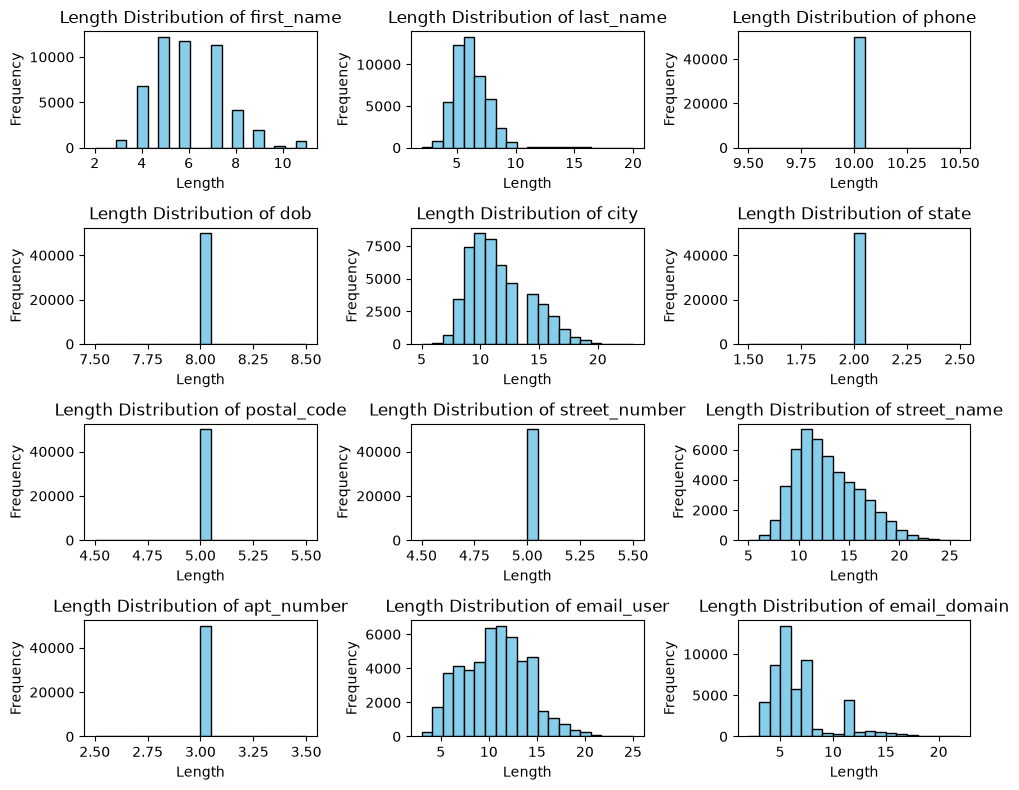

In [9]:
# See histogram of all field's lengths for certain fields to be easier to hash and block
field_lengths = data_clean.copy()
field_lengths.drop(columns=['cluster_id','is_duplicate'], inplace=True)
for col in data_clean.columns:
    field_lengths[col] = data_clean[col].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 8))
for ax, col in zip(axes.flatten(), field_lengths.columns):
    ax.hist(field_lengths[col], bins=20, color='skyblue', edgecolor='black')
    ax.set_title(f'Length Distribution of {col}')
    ax.set_xlabel('Length')
    ax.set_ylabel('Frequency')
    
plt.tight_layout()
plt.show()